In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Bird baths in Australia

In [2]:
# load the data
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-08-31/bird_baths.csv'
birds = pd.read_csv(url)
birds.head()

,survey_year,urban_rural,bioregions,bird_type,bird_count
0,2014.0,Urban,South Eastern Queensland,Bassian Thrush,0
1,2014.0,Urban,South Eastern Queensland,Chestnut-breasted Mannikin,0
2,2014.0,Urban,South Eastern Queensland,Wild Duck,0
3,2014.0,Urban,South Eastern Queensland,Willie Wagtail,0
4,2014.0,Urban,South Eastern Queensland,Regent Bowerbird,0


Our **goal** is to predict the probability of whether we’ll see a bird at a bird bath in Australia, given info like what kind of bird we’re looking for and whether the bird bath is in an urban or rural location.

We'll focus on birds from the following list.

In [3]:
birds_list = [
    'Noisy Miner',
    'Australian Magpie',
    'Rainbow Lorikeet',
    'Red Wattlebird',
    'Superb Fairy-wren',
    'Magpie-lark',
    'Pied Currawong',
    'Crimson Rosella',
    'Eastern Spinebill',
    'Spotted Dove',
    "Lewin's Honeyeater",
    'Satin Bowerbird',
    'Crested Pigeon',
    'Grey Fantail',
    'Red-browed Finch',
]

**Part 1:** Filter out the bird types that are not on the `birds_list` list.

In [8]:
# your code here
pop_birds= birds[birds['bird_type'].map(lambda x: x in birds_list)]

In [10]:
pop_birds

,survey_year,urban_rural,bioregions,bird_type,bird_count
22,2014.0,Urban,South Eastern Queensland,Satin Bowerbird,0
24,2014.0,Urban,South Eastern Queensland,Eastern Spinebill,0
35,2014.0,Urban,South Eastern Queensland,Red Wattlebird,0
44,2014.0,Urban,South Eastern Queensland,Crimson Rosella,0
84,2014.0,Urban,South Eastern Queensland,Australian Magpie,0
...,...,...,...,...,...
160994,NaN,NaN,NaN,Rainbow Lorikeet,235
161022,NaN,NaN,NaN,Red-browed Finch,117
161040,NaN,NaN,NaN,Noisy Miner,292
161046,NaN,NaN,NaN,Spotted Dove,151


**Part 2:** Add a `bird` column to the DataFrame, where the value is `1` when `bird_count>0`, and `0` when `bird_count=0`.

In [17]:
# your code here

vals = pop_birds['bird_count'].map(lambda x: x >=1).astype(int)

In [18]:
pop_birds['bird'] = vals

/var/folders/kn/55jn3px126z8xdxt60nbxw5h0000gn/T/ipykernel_6218/2938919185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_birds['bird'] = vals


In [19]:
pop_birds['bird']

22        0
24        0
35        0
44        0
84        0
         ..
160994    1
161022    1
161040    1
161046    1
161056    1
Name: bird, Length: 14295, dtype: int64

Drop the `bird_count` column

In [20]:
# your code here
birds=pop_birds.drop('bird_count', axis=1)

**Part 3:** How likely are you to see birds of different types (Australian Magpie, Crested Pigeon,...) in different locations (rural, urban)?

**Hint**: use `pd.pivot_table`.

In [24]:
# your code here
probability = birds.pivot_table('bird', index = 'bird_type', columns = 'urban_rural', aggfunc='mean')

In [25]:
probability

urban_rural,Rural,Urban
bird_type,,
Australian Magpie,0.258503,0.282675
Crested Pigeon,0.095238,0.147416
Crimson Rosella,0.224490,0.135258
Eastern Spinebill,0.295918,0.100304
Grey Fantail,0.282313,0.060790
Lewin's Honeyeater,0.282313,0.075988
Magpie-lark,0.112245,0.193009
Noisy Miner,0.200680,0.354103
Pied Currawong,0.108844,0.189970


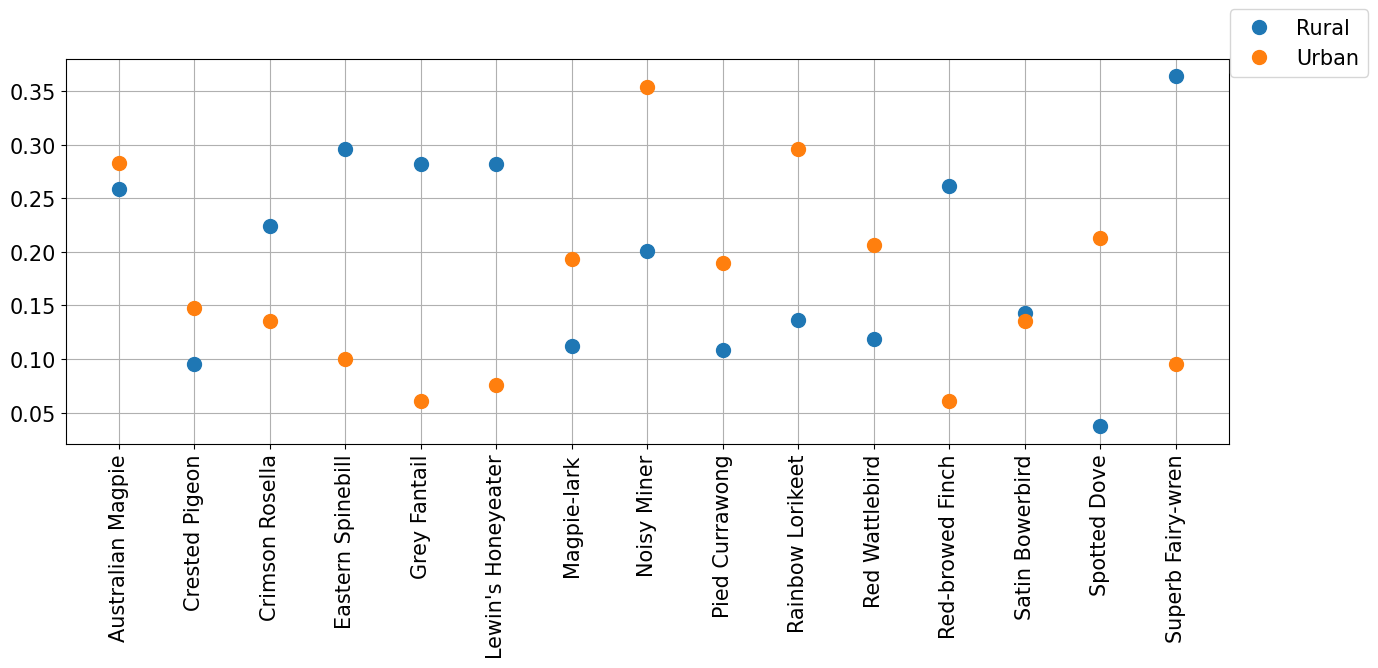

In [26]:
# run this cell to plot probabilities
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(probability.Rural,'o',markersize='10', label='Rural')
ax.plot(probability.Urban,'o',markersize='10', label='Urban')
ax.grid(True)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
fig.legend(fontsize=15)
plt.show()

We'll use the `urban_rural`, `bird_type` and `bioregions` features to predict these probabilities.

**Part 4:** Define the feature matrix X (columns `urban_rural`, `bird_type` and `bioregions`) and the target vector y (`bird` column) from the dataframe, and then split X and y into training and testing sets.

In [27]:
# your code here
X = birds[['urban_rural', 'bird_type', 'bioregions']]

y = birds['bird']

In [28]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y)

**Part 5:** build a pipeline with the following steps: an imputer, a one-hot-encoder, and a logistic regression model.

In [42]:
# your code here
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [31]:
# instantiate the model
log_clf = LogisticRegression(max_iter = 2000)

In [34]:
pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder()),
    ('clf', log_clf)
])

Fit your pipeline to the training data

In [35]:
# your code here
pipe.fit(X,y)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder()),
                ('clf', LogisticRegression(max_iter=2000))])

Use the `predict_proba` method to compute the seeing-a-bird probability on the testing data.

In [38]:
# your code here
# probability of label = 1 (see bird)
proba = pipe.predict_proba(X_test)[:,1]
proba

array([0.14053567, 0.25583885, 0.17912636, ..., 0.16153224, 0.1322054 ,
       0.21503524])

Run the following two cells.

In [40]:
# this cell creates a dataframe with the computed probabilities
results = X_test.copy()
results['proba'] = proba
results

,urban_rural,bird_type,bioregions,proba
26290,Urban,Lewin's Honeyeater,Sydney Basin,0.140536
107590,Urban,Rainbow Lorikeet,NSW North Coast,0.255839
117726,Urban,Superb Fairy-wren,Sydney Basin,0.179126
102667,Rural,Australian Magpie,South Eastern Queensland,0.270234
112046,Urban,Grey Fantail,NSW North Coast,0.135440
...,...,...,...,...
150434,Urban,Eastern Spinebill,Victorian Volcanic Plain,0.154438
81382,Rural,Magpie-lark,South Eastern Highlands,0.187443
65160,Rural,Lewin's Honeyeater,Sydney Basin,0.161532
126168,Urban,Crested Pigeon,Sydney Basin,0.132205


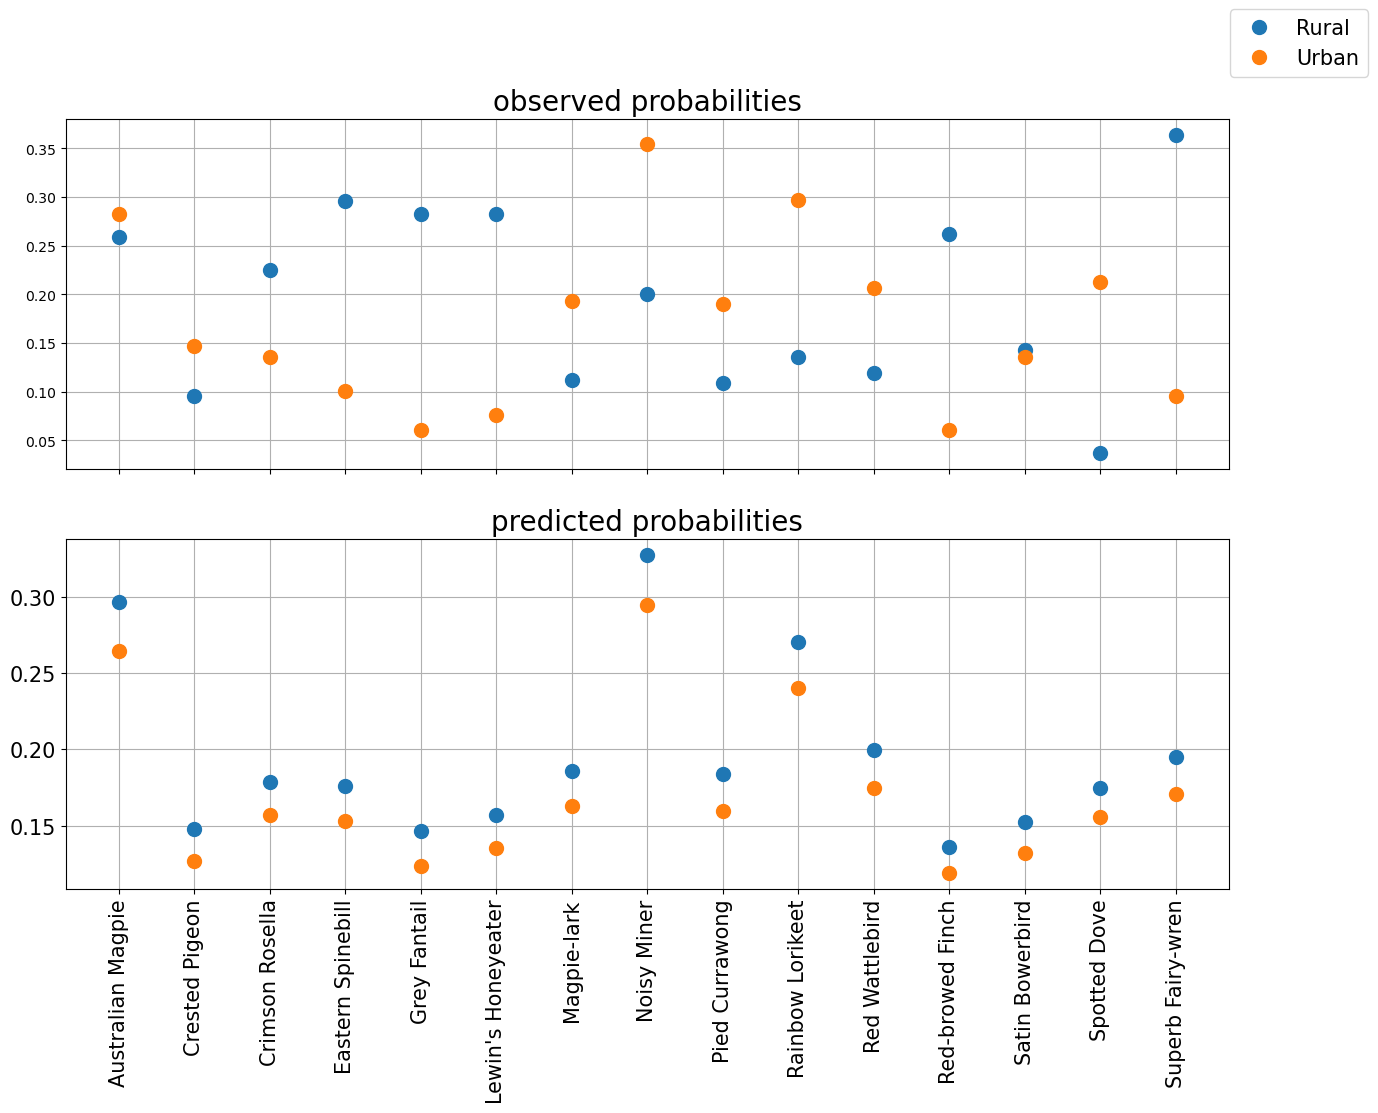

In [41]:
# this cell plots the observed and computed probabilities
probability_test = pd.pivot_table(data=results, values='proba', index='bird_type', columns='urban_rural', aggfunc = 'mean')

fig, ax = plt.subplots(2,1,figsize=(15,10),sharex=True)

ax[0].plot(probability.Rural,'o',markersize='10', label='Rural')
ax[0].plot(probability.Urban,'o',markersize='10', label='Urban')
ax[0].grid(True)
ax[0].set_title('observed probabilities', fontsize=20)

ax[1].plot(probability_test.Rural,'o',markersize='10')
ax[1].plot(probability_test.Urban,'o',markersize='10')
ax[1].grid(True)
ax[1].set_title('predicted probabilities', fontsize=20)
plt.xticks(fontsize=15,rotation=90)
plt.yticks(fontsize=15)
fig.legend(fontsize=15)
plt.show()

The predicted probabilities don't look great. 

**Part 6:** Add polynomial features (of degree 2) to your pipeline, and repeat **Part 5**

In [44]:
# your code here
pipe2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder()),
    ('poly_features', PolynomialFeatures(degree=2)),
    ('clf', log_clf)
])

In [45]:
pipe2.fit(X,y)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder()),
                ('poly_features', PolynomialFeatures()),
                ('clf', LogisticRegression(max_iter=2000))])

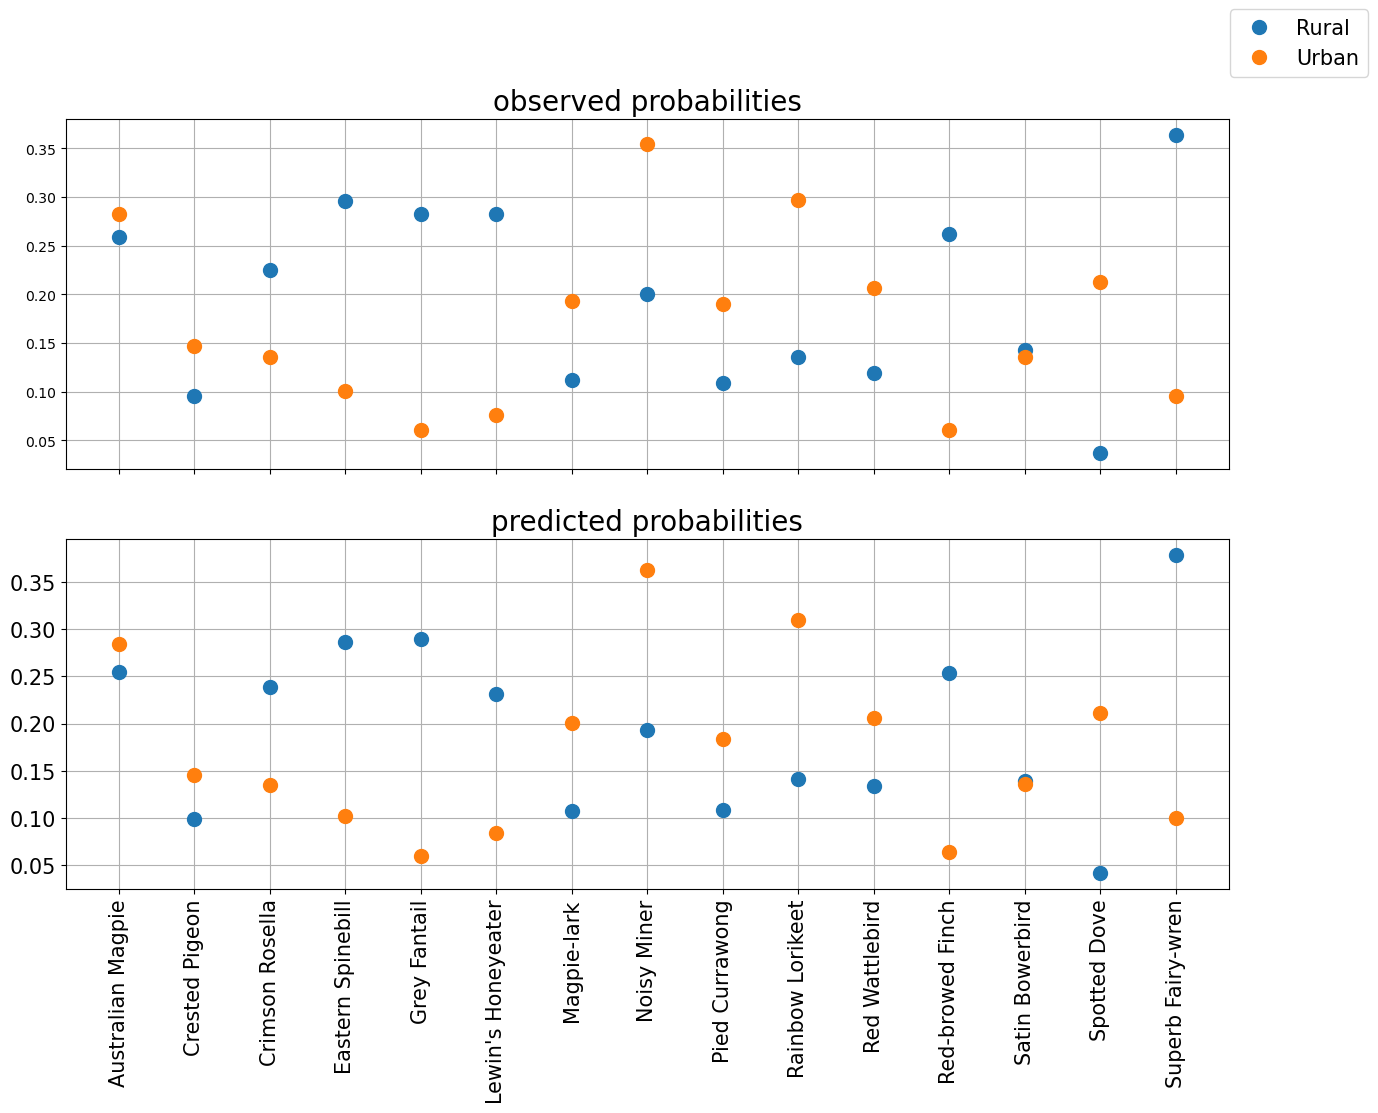

In [46]:
proba = pipe2.predict_proba(X_test)[:,1]

results = X_test.copy()
results['proba'] = proba

# this cell plots the observed and computed probabilities
probability_test = pd.pivot_table(data=results, values='proba', index='bird_type', columns='urban_rural', aggfunc = 'mean')

fig, ax = plt.subplots(2,1,figsize=(15,10),sharex=True)

ax[0].plot(probability.Rural,'o',markersize='10', label='Rural')
ax[0].plot(probability.Urban,'o',markersize='10', label='Urban')
ax[0].grid(True)
ax[0].set_title('observed probabilities', fontsize=20)

ax[1].plot(probability_test.Rural,'o',markersize='10')
ax[1].plot(probability_test.Urban,'o',markersize='10')
ax[1].grid(True)
ax[1].set_title('predicted probabilities', fontsize=20)
plt.xticks(fontsize=15,rotation=90)
plt.yticks(fontsize=15)
fig.legend(fontsize=15)
plt.show()